# Modelo de Exposición al Incumplimiento (EI)
## Mezcla de Expertos (MoE) — modelo final

Predicción del **Factor = EI / Saldo** en créditos revolventes.

Pipeline de **dos etapas**:
1. **Etapa 1** — clasificador de régimen: `bajó` / `estable` / `subió`.
2. **Etapa 2** — un experto de regresión LightGBM por régimen.
3. **Predicción final (mezcla suave):**
$$\hat{y}(x)=\sum_{z}\,P(z\mid x)\;\cdot\;\text{experto}_z(x)$$


## 0. Configuración e imports

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix)
import lightgbm as lgb

SEED       = 42
DATA_PATH  = 'BaseEI.xlsx'
Z_LO, Z_HI = 0.95, 1.05   # umbrales de régimen sobre el Factor
np.random.seed(SEED)

def metrics(y, p):
    return {'RMSE': float(np.sqrt(mean_squared_error(y, p))),
            'MAE':  float(mean_absolute_error(y, p)),
            'R2':   float(r2_score(y, p))}


## 1. Carga de datos

In [2]:
df = pd.read_excel(DATA_PATH, sheet_name='Datos')
TARGET = 'Factor'
print('Dimensiones:', df.shape)
print('Factor  media=%.3f  mediana=%.3f  min=%.3f  max=%.3f' %
      (df[TARGET].mean(), df[TARGET].median(), df[TARGET].min(), df[TARGET].max()))
df.head()


Dimensiones: (10000, 14)
Factor  media=1.025  mediana=1.028  min=0.000  max=2.710


,mar_emp,DiasMora,Factor,STOTAL,df_Life_M,utilizacion,prom_saldo_6m,prom_diasmora_6m,prom_df_life_M_6m,prom_utilizacion_6m,prom_saldo_12m,prom_diasmora_12m,prom_df_life_M_12m,prom_utilizacion_12m
0,0,0,0.359527,1121.00,131,0.004484,1.105915e+03,0.0,128.5,0.004424,1.088168e+03,0.0,125.5,0.004353
1,0,0,0.357444,1781.20,132,0.008906,1.756715e+03,0.0,129.5,0.008784,1.728425e+03,0.0,126.5,0.008642
2,0,0,0.882939,26996677.02,74,0.067200,2.794959e+07,0.0,71.5,0.069572,2.902751e+07,0.0,68.5,0.081019
3,0,0,0.895963,26604235.70,75,0.066223,2.757113e+07,0.0,72.5,0.068630,2.866305e+07,0.0,69.5,0.077876
4,0,0,0.939088,25382522.19,78,0.063182,2.639019e+07,0.0,75.5,0.065690,2.753865e+07,0.0,72.5,0.068549


## 2. Preprocesamiento

- `log1p` a las variables monetarias (asimetría extrema).
- One-Hot de `mar_emp` (segmento).

In [3]:
SKEWED = ['STOTAL', 'prom_saldo_6m', 'prom_saldo_12m']
for c in SKEWED:
    df[c + '_log'] = np.log1p(df[c])

mar_dummies = pd.get_dummies(df['mar_emp'], prefix='me', drop_first=True).astype(float)
df = pd.concat([df, mar_dummies], axis=1)
OHE_COLS = list(mar_dummies.columns)
print('Dummies de mar_emp:', OHE_COLS)


Dummies de mar_emp: ['me_1']


## 3. Partición y codificación sin fuga de datos

Partición **64 / 16 / 20** (train / val / test), semilla fija.
El *target encoding* y el *winsorize* se calculan **solo con train**.

In [4]:
idx = np.arange(len(df))
idx_tv, idx_te = train_test_split(idx, test_size=0.20, random_state=SEED)
idx_tr, idx_va = train_test_split(idx_tv, test_size=0.20, random_state=SEED)
print(f'train={len(idx_tr)}  val={len(idx_va)}  test={len(idx_te)}')

# Target encoding de mar_emp (media del Factor por segmento, SOLO train)
te_map    = df.loc[idx_tr].groupby('mar_emp')[TARGET].mean()
global_te = df.loc[idx_tr, TARGET].mean()
df['mar_emp_te'] = df['mar_emp'].map(te_map).fillna(global_te)


train=6400  val=1600  test=2000


## 4. Ingeniería de variables

Variables que capturan la **dinámica** del cliente antes del incumplimiento:
deltas (spot − histórico), aceleraciones (6m − 12m), ratios, interacciones y banderas.

In [5]:
df['delta_utiliz_6m']  = df['utilizacion'] - df['prom_utilizacion_6m']
df['delta_utiliz_12m'] = df['utilizacion'] - df['prom_utilizacion_12m']
df['delta_mora_6m']    = df['DiasMora']    - df['prom_diasmora_6m']
df['delta_mora_12m']   = df['DiasMora']    - df['prom_diasmora_12m']
df['delta_vida_6m']    = df['df_Life_M']   - df['prom_df_life_M_6m']
df['delta_vida_12m']   = df['df_Life_M']   - df['prom_df_life_M_12m']
df['accel_utiliz']     = df['prom_utilizacion_6m'] - df['prom_utilizacion_12m']
df['accel_mora']       = df['prom_diasmora_6m']    - df['prom_diasmora_12m']
df['accel_saldo']      = df['prom_saldo_6m_log']   - df['prom_saldo_12m_log']
df['ratio_saldo_6m']   = df['STOTAL_log'] - df['prom_saldo_6m_log']
df['ratio_saldo_12m']  = df['STOTAL_log'] - df['prom_saldo_12m_log']
df['mora_ratio_12m']   = df['DiasMora'] / (df['prom_diasmora_12m'] + 1.0)
df['mora_x_utiliz']    = df['DiasMora'] * df['utilizacion']
df['mora_x_saldo_log'] = df['DiasMora'] * df['STOTAL_log']
df['utiliz_sq']        = df['utilizacion'] ** 2
df['alta_utiliz']      = (df['utilizacion'] >= 0.90).astype(float)
df['mora_creciente']   = (df['DiasMora']    >  df['prom_diasmora_12m']).astype(float)
df['saldo_creciente']  = (df['STOTAL_log']  >  df['prom_saldo_12m_log']).astype(float)
df['utiliz_creciente'] = (df['utilizacion'] >  df['prom_utilizacion_12m']).astype(float)


Conjunto final de variables y matrices X / y:

In [6]:
BASE_COLS = ['DiasMora','STOTAL_log','df_Life_M','utilizacion',
             'prom_saldo_6m_log','prom_diasmora_6m','prom_df_life_M_6m','prom_utilizacion_6m',
             'prom_saldo_12m_log','prom_diasmora_12m','prom_df_life_M_12m','prom_utilizacion_12m']
FE_COLS = ['delta_utiliz_6m','delta_utiliz_12m','delta_mora_6m','delta_mora_12m',
           'delta_vida_6m','delta_vida_12m','accel_utiliz','accel_mora','accel_saldo',
           'ratio_saldo_6m','ratio_saldo_12m','mora_ratio_12m','mora_x_utiliz',
           'mora_x_saldo_log','utiliz_sq','alta_utiliz','mora_creciente',
           'saldo_creciente','utiliz_creciente']
ALL_COLS = BASE_COLS + FE_COLS + ['mar_emp_te'] + OHE_COLS
print('Total de variables:', len(ALL_COLS))

def XY(ix):
    return (df.loc[ix, ALL_COLS].astype(float).values,
            df.loc[ix, TARGET].astype(float).values)

Xtr, ytr = XY(idx_tr)   # target REAL de train
Xva, yva = XY(idx_va)
Xte, yte = XY(idx_te)   # target REAL de test (evaluación honesta)

# Winsorize SOLO el target de entrenamiento
p01, p99 = np.quantile(ytr, [0.01, 0.99])
ytr_w = np.clip(ytr, p01, p99)
print(f'Winsorize train a [{p01:.3f}, {p99:.3f}]')


Total de variables: 33
Winsorize train a [0.067, 2.184]


## 5. Etapa 1 — Clasificador de régimen

Regímenes a partir del Factor: **bajó** (<0.95), **estable** ([0.95, 1.05]), **subió** (>1.05).
Un LightGBM multiclase estima $P(\text{régimen}\mid x)$.

In [7]:
def to_zone(y):
    z = np.ones(len(y), int); z[y < Z_LO] = 0; z[y > Z_HI] = 2; return z

ztr, zva, zte = to_zone(ytr), to_zone(yva), to_zone(yte)
ZN = ['bajó', 'estable', 'subió']
for k in range(3):
    print(f'  {ZN[k]:8s} {(ztr==k).mean()*100:5.1f}%  en train')

clf = lgb.LGBMClassifier(objective='multiclass', num_class=3, n_estimators=600,
                         learning_rate=0.03, num_leaves=63, min_child_samples=20,
                         subsample=0.8, colsample_bytree=0.7, reg_lambda=2.0,
                         random_state=SEED, n_jobs=-1, verbose=-1)
clf.fit(Xtr, ztr)
P_va, P_te = clf.predict_proba(Xva), clf.predict_proba(Xte)
print(f'\nAccuracy clasificador (test): {accuracy_score(zte, P_te.argmax(1)):.3f}')


  bajó      17.9%  en train
  estable   44.1%  en train
  subió     38.1%  en train



Accuracy clasificador (test): 0.622


## 6. Etapa 2 — Expertos por régimen + mezcla suave

Un regresor LightGBM por régimen, entrenado solo con su sub-población.
La predicción combina los expertos ponderando por la probabilidad del clasificador.

In [8]:
def make_reg():
    return lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=63,
                             min_child_samples=20, subsample=0.8, colsample_bytree=0.7,
                             reg_alpha=0.1, reg_lambda=3.0, random_state=SEED,
                             n_jobs=-1, verbose=-1)

experts, exp_te = {}, {}
for z in range(3):
    m = ztr == z
    experts[z] = make_reg().fit(Xtr[m], ytr_w[m])   # cada experto ve su régimen
    exp_te[z]  = experts[z].predict(Xte)

# Mezcla suave: sum_z P(z|x) * experto_z(x)
p_moe = sum(P_te[:, z] * exp_te[z] for z in range(3))
print('MoE entrenado.')


MoE entrenado.


## 7. Resultados sobre el conjunto de prueba (Factor real)

In [9]:
res = metrics(yte, p_moe)
print('='*40)
print('  MoE (2 etapas) — conjunto de prueba')
print('='*40)
print(f"  RMSE = {res['RMSE']:.4f}")
print(f"  MAE  = {res['MAE']:.4f}")
print(f"  R2   = {res['R2']:.4f}")


  MoE (2 etapas) — conjunto de prueba
  RMSE = 0.2806
  MAE  = 0.1527
  R2   = 0.2437


## 8. Predicho vs. real

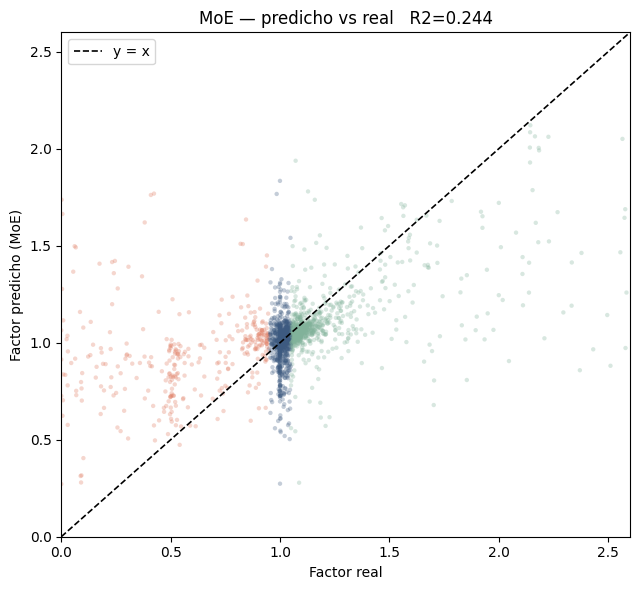

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6))
colors = np.array(['#E07A5F', '#3D5A80', '#81B29A'])[zte]
ax.scatter(yte, p_moe, s=10, alpha=0.30, c=colors, edgecolors='none')
ax.plot([0, 2.6], [0, 2.6], 'k--', lw=1.2, label='y = x')
ax.set_xlim(0, 2.6); ax.set_ylim(0, 2.6)
ax.set_xlabel('Factor real'); ax.set_ylabel('Factor predicho (MoE)')
ax.set_title(f"MoE — predicho vs real   R2={res['R2']:.3f}")
ax.legend(); plt.tight_layout(); plt.show()


## 9. Matriz de confusión del clasificador de régimen

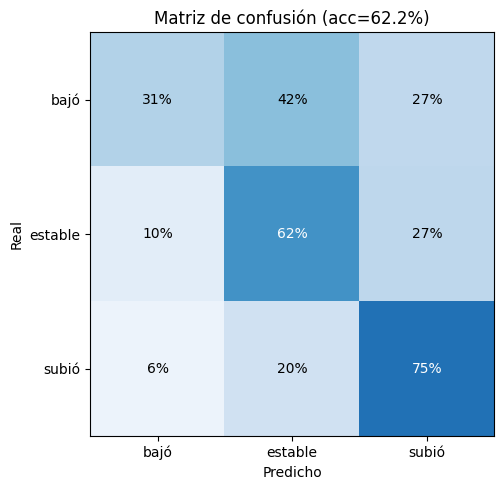

In [11]:
cm = confusion_matrix(zte, P_te.argmax(1), labels=[0,1,2])
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(ZN); ax.set_yticklabels(ZN)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión (acc={cm.diagonal().sum()/cm.sum():.1%})')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cmn[i,j]:.0%}', ha='center', va='center',
                color='white' if cmn[i,j] > 0.5 else 'black')
plt.tight_layout(); plt.show()


## 10. Función para puntuar nuevos clientes

`predecir_factor(df_nuevo)` aplica todo el pipeline (FE + 2 etapas) y devuelve el Factor
estimado junto con las probabilidades de régimen.

In [12]:
def _features(d):
    d = d.copy()
    for c in SKEWED:
        d[c + '_log'] = np.log1p(d[c])
    for c in OHE_COLS:
        cat = c.replace('me_', '')
        d[c] = (d['mar_emp'].astype(str) == cat).astype(float)
    d['mar_emp_te']    = d['mar_emp'].map(te_map).fillna(global_te)
    d['delta_utiliz_6m']  = d['utilizacion'] - d['prom_utilizacion_6m']
    d['delta_utiliz_12m'] = d['utilizacion'] - d['prom_utilizacion_12m']
    d['delta_mora_6m']    = d['DiasMora']    - d['prom_diasmora_6m']
    d['delta_mora_12m']   = d['DiasMora']    - d['prom_diasmora_12m']
    d['delta_vida_6m']    = d['df_Life_M']   - d['prom_df_life_M_6m']
    d['delta_vida_12m']   = d['df_Life_M']   - d['prom_df_life_M_12m']
    d['accel_utiliz']     = d['prom_utilizacion_6m'] - d['prom_utilizacion_12m']
    d['accel_mora']       = d['prom_diasmora_6m']    - d['prom_diasmora_12m']
    d['accel_saldo']      = d['prom_saldo_6m_log']   - d['prom_saldo_12m_log']
    d['ratio_saldo_6m']   = d['STOTAL_log'] - d['prom_saldo_6m_log']
    d['ratio_saldo_12m']  = d['STOTAL_log'] - d['prom_saldo_12m_log']
    d['mora_ratio_12m']   = d['DiasMora'] / (d['prom_diasmora_12m'] + 1.0)
    d['mora_x_utiliz']    = d['DiasMora'] * d['utilizacion']
    d['mora_x_saldo_log'] = d['DiasMora'] * d['STOTAL_log']
    d['utiliz_sq']        = d['utilizacion'] ** 2
    d['alta_utiliz']      = (d['utilizacion'] >= 0.90).astype(float)
    d['mora_creciente']   = (d['DiasMora']    >  d['prom_diasmora_12m']).astype(float)
    d['saldo_creciente']  = (d['STOTAL_log']  >  d['prom_saldo_12m_log']).astype(float)
    d['utiliz_creciente'] = (d['utilizacion'] >  d['prom_utilizacion_12m']).astype(float)
    return d[ALL_COLS].astype(float).values

def predecir_factor(df_nuevo):
    X = _features(df_nuevo)
    P = clf.predict_proba(X)
    pred = sum(P[:, z] * experts[z].predict(X) for z in range(3))
    out = pd.DataFrame({'factor_pred': pred,
                        'P_bajo': P[:,0], 'P_estable': P[:,1], 'P_subio': P[:,2]})
    return out

# Ejemplo: puntuar las primeras 5 filas del test
predecir_factor(df.loc[idx_te[:5]])


,factor_pred,P_bajo,P_estable,P_subio
0,1.157959,0.007857,0.064722,0.927421
1,1.068674,0.009823,0.440300,0.549877
2,0.968001,0.088021,0.886551,0.025427
3,1.028298,0.113737,0.506489,0.379774
4,1.021712,0.054795,0.541511,0.403695
